In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='white')

import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import xgboost as xgb
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.model_selection import KFold

import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [3]:
my_colors = ["#c6b34e","#95354a", "#57b9a8","#b0ddff", "#426872","#215c97", "#02b6b4","#b05468","#cd9f62","#aaaaaa","#8fce00","#827861"]
my_palette = sns.color_palette(my_colors)
sns.set_palette(my_palette)
from matplotlib.colors import ListedColormap
colors = ['#ffffcd', '#ffeaa4', '#ffca2a','#c6b34e']
my_cmap = sns.color_palette(colors)
cmap = ListedColormap(colors)

In [4]:
df = pd.read_csv('/content/Student feedback data.csv')
df.head()

,Timestamp,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Raise some changes or improvement you want. If any?,overall rating
0,2025/11/10 11:51:24 PM GMT+5:30,Dipika Sarkar,18-22,Royal Global University,Female,Course,Neutral,Understanding,Less Motivated,Fair,not any,3
1,2025/11/11 12:12:27 AM GMT+5:30,Nirok Asher G Momin,22 Above,The Assam Royal Global University,Female,Resources,Neutral,Time Management,Neutral,Fair,not any,3
2,2025/11/11 9:41:41 PM GMT+5:30,Dhanjita Boro,18-22,Pandit Deendayal Upadhyaya Adarsha mahavidyalaya,Female,Course,Neutral,Limited Resources,Neutral,Fair,I dunno,3
3,2025/11/11 9:42:01 PM GMT+5:30,Suzina parbin,22 Above,The Assam Royal Global University,Female,Course,Satisfied,Time Management,Neutral,Good,Faculty should be more resourceful,4
4,2025/11/11 9:47:25 PM GMT+5:30,Afrida Begum,18-22,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,not any,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 12 columns):
 #   Column                                                                      Non-Null Count  Dtype 
---  ------                                                                      --------------  ----- 
 0   Timestamp                                                                   39 non-null     object
 1   Your Name                                                                   39 non-null     object
 2   Age Group                                                                   39 non-null     object
 3   School/College Name                                                         39 non-null     object
 4   Gender                                                                      39 non-null     object
 5   What do you like most about your education experience ?                     39 non-null     object
 6   How do you feel about the teaching methods used in your clas

***DATA CLEANING***


In [6]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Timestamp', 'Your Name', 'Age Group', 'School/College Name', 'Gender',
       'What do you like most about your education experience ?',
       'How do you feel about the teaching methods used in your classes?',
       'What are the biggest challenges you face in your studies?',
       'How motivated do you feel to participate in class activities?',
       'How do you feel the school supports for your personal and academic growth?',
       'Raise some changes or improvement you want. If any?',
       'overall rating'],
      dtype='object')


In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Date'] = df['Timestamp'].dt.date
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = df['Timestamp'].dt.time
df['Hour'] = df['Timestamp'].dt.hour

df = df.drop(['Timestamp'], axis=1)

In [8]:
df.sample(6)

,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Raise some changes or improvement you want. If any?,overall rating,Date,Time,Hour
15,Saniya Nazir,18-22,Nepni college of nursing,Female,Teaching,Satisfied,Time Management,Neutral,Good,not any,3,2025-11-11,22:12:48,22
30,GOPESH DEY,22 Above,Mangaldai college,Male,Course,Neutral,Low Facilities,Neutral,Fair,System,3,2025-11-12,17:07:56,17
0,Dipika Sarkar,18-22,Royal Global University,Female,Course,Neutral,Understanding,Less Motivated,Fair,not any,3,2025-11-10,23:51:24,23
11,Afrida Hussain,18-22,Rahman institute of nursing and paramedical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:59:56,21
37,Priyam agrawal,22 Above,Shri ramdeoboba college of engineering and man...,Male,Course,Very Satisfied,Time Management,Neutral,Good,NaN,5,2025-11-13,00:04:02,0
20,Sapina Begom,18-22,Royal Global University,Female,Course,Satisfied,Time Management,Neutral,Good,NaN,5,2025-11-11,22:55:53,22


In [9]:
df['Age Group'] = df['Age Group'].str.extract(r'(\d+)').astype('Int64')


In [10]:
df = df.replace(['', 'NA', 'null'], np.nan)

In [11]:
df.sample(3)

,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Raise some changes or improvement you want. If any?,overall rating,Date,Time,Hour
27,Yahya,22,PDUAM,Male,Resources,Satisfied,Low Facilities,Very Motivated,Good,NaN,3,2025-11-12,08:13:29,8
13,Runi Kar,22,Mangaldai College,Male,Teaching,Satisfied,Expenses,Neutral,Good,Fees expenses,4,2025-11-11,22:07:13,22
12,Tehsin Ahmed,18,Rahman institute of nursing and paramedical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,22:06:51,22


***DATA PREPROCESSING***

In [12]:
def preprocess_text(textdata):

    textdata = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", textdata.lower())
    textdata = re.sub(r"[^\w\s]", "", textdata)

    textdata = re.sub(r'\b[0-9]+\b\s*', '', textdata)

    textdata = ''.join([char for char in textdata if char not in string.punctuation])

    tokens = word_tokenize(textdata)

    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)
df_renamed = df.rename(columns={
    'Raise some changes or improvement you want. If any?': 'Feedback',
}, inplace=True)
df.tail(10)

,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Feedback,overall rating,Date,Time,Hour
29,Kamal Ahmed,22,RGU Guwahati,Male,Teaching,Satisfied,Time Management,Neutral,Good,NaN,3,2025-11-12,10:36:34,10
30,GOPESH DEY,22,Mangaldai college,Male,Course,Neutral,Low Facilities,Neutral,Fair,System,3,2025-11-12,17:07:56,17
31,Maruf Ali,14,Srimanta Sankerdev adarsha sishu L.P Sc...,Male,Resources,Very Satisfied,Time Management,Very Motivated,Excellent,School painting\n,1,2025-11-12,18:26:58,18
32,Eliza begum,18,The Royal global University,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,Focus more on practical learning,1,2025-11-12,19:00:05,19
33,Nurjamal hoque,14,Ulubari h.s. school,Male,Course,Very Satisfied,Understanding,Very Motivated,Excellent,NaN,5,2025-11-12,19:04:05,19
34,Gulesta Begum,22,KJB senior secondary school,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,Focus more on practical learning.\nImprove tea...,5,2025-11-12,19:06:18,19
35,Gulesta Begum,22,Kjb senior secondary school,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,Focus more on practical learning.\nImprove tea...,5,2025-11-12,19:09:28,19
36,Barsha debnath,18,Rg baruah college,Female,Teaching,Satisfied,Time Management,Very Motivated,Excellent,Sports day,4,2025-11-12,23:49:20,23
37,Priyam agrawal,22,Shri ramdeoboba college of engineering and man...,Male,Course,Very Satisfied,Time Management,Neutral,Good,NaN,5,2025-11-13,00:04:02,0
38,DOLLA CHAKRABORTY,18,ARYA VIDYAPEETH COLLEGE AUTONOMOUS,Female,Support,Neutral,Understanding,Neutral,Excellent,NaN,5,2025-11-13,00:16:12,0


In [13]:
!pip install langdetect
from langdetect import detect

def detect_language(text):
    try:
        lang = detect(text)
        return lang
    except:
        return None

df['Language'] = df['Feedback'].apply(detect_language)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=0d98b112946f87bac3ff73954add3bb609a0fe470b20fc6bf35be0435e763e41
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [14]:
df['Language'].unique()

array(['tl', 'it', 'en', 'fr', None, 'nl', 'no', 'da'], dtype=object)

In [15]:
df


,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Feedback,overall rating,Date,Time,Hour,Language
0,Dipika Sarkar,18,Royal Global University,Female,Course,Neutral,Understanding,Less Motivated,Fair,not any,3,2025-11-10,23:51:24,23,tl
1,Nirok Asher G Momin,22,The Assam Royal Global University,Female,Resources,Neutral,Time Management,Neutral,Fair,not any,3,2025-11-11,00:12:27,0,tl
2,Dhanjita Boro,18,Pandit Deendayal Upadhyaya Adarsha mahavidyalaya,Female,Course,Neutral,Limited Resources,Neutral,Fair,I dunno,3,2025-11-11,21:41:41,21,it
3,Suzina parbin,22,The Assam Royal Global University,Female,Course,Satisfied,Time Management,Neutral,Good,Faculty should be more resourceful,4,2025-11-11,21:42:01,21,en
4,Afrida Begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,not any,5,2025-11-11,21:47:25,21,tl
5,Rishika singha,15,The Assam Royal Global University,Female,Course,Neutral,Limited Resources,Neutral,Fair,BA Geography related book should be available ...,3,2025-11-11,21:47:53,21,en
6,Afrida begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:50:16,21,en
7,Crosby Sangma,18,"St Edmunds College, Shillong",Prefer not to say,Course,Satisfied,Time Management,Neutral,Excellent,Practically Teaching,4,2025-11-11,21:50:39,21,en
8,Chebanora M Momin,18,The Assam Royal Global University,Female,Resources,Satisfied,Time Management,Neutral,Fair,practically Teaching,5,2025-11-11,21:50:52,21,en
9,Afrida begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:51:32,21,en


In [16]:


def map_language_and_clean(language_code):

    if pd.isna(language_code):
      return 'detected'
    if language_code is 'None' or 'not any':
        return 'Language Missing/Undetected'




In [17]:
language_map = {
    'tl': 'Tagalog (Filipino)',
    'it': 'Italian',
    'en': 'English',
    'fr': 'French',
    'nl': 'Dutch',
    'no': 'Norwegian',
    'da': 'Danish',
}

df['Language'] = df['Feedback'].apply(detect_language)

df['Language'] = df['Language'].map(language_map)
df['Language'].unique()

array(['Tagalog (Filipino)', 'Italian', 'English', 'French', nan, 'Dutch',
       'Norwegian', 'Danish'], dtype=object)

In [18]:
df.sample(5)

,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Feedback,overall rating,Date,Time,Hour,Language
34,Gulesta Begum,22,KJB senior secondary school,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,Focus more on practical learning.\nImprove tea...,5,2025-11-12,19:06:18,19,English
6,Afrida begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:50:16,21,English
0,Dipika Sarkar,18,Royal Global University,Female,Course,Neutral,Understanding,Less Motivated,Fair,not any,3,2025-11-10,23:51:24,23,Tagalog (Filipino)
36,Barsha debnath,18,Rg baruah college,Female,Teaching,Satisfied,Time Management,Very Motivated,Excellent,Sports day,4,2025-11-12,23:49:20,23,English
18,Mujahidul Islam,18,"PDUAM, DALGAON",Male,Resources,Satisfied,Time Management,Neutral,Fair,NaN,3,2025-11-11,22:15:00,22,NaN


**Feature Engineering**


In [19]:
df['Feedback'].str.len()
df['Word_Count'] = df['Feedback'].fillna('').apply(lambda x: len(x.split()))

In [20]:
df.sort_values(by='Feedback', ascending=False).head(10)

,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Feedback,overall rating,Date,Time,Hour,Language,Word_Count
6,Afrida begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:50:16,21,English,25
9,Afrida begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:51:32,21,English,25
11,Afrida Hussain,18,Rahman institute of nursing and paramedical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:59:56,21,English,25
12,Tehsin Ahmed,18,Rahman institute of nursing and paramedical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,22:06:51,22,English,25
23,Nabajyoti,22,Adtu,Male,Resources,Very Dissatisfied,Low Facilities,Neutral,Fair,"single hand can't do any betterment, no point ...",2,2025-11-11,23:50:01,23,English,10
8,Chebanora M Momin,18,The Assam Royal Global University,Female,Resources,Satisfied,Time Management,Neutral,Fair,practically Teaching,5,2025-11-11,21:50:52,21,English,2
15,Saniya Nazir,18,Nepni college of nursing,Female,Teaching,Satisfied,Time Management,Neutral,Good,not any,3,2025-11-11,22:12:48,22,Tagalog (Filipino),2
0,Dipika Sarkar,18,Royal Global University,Female,Course,Neutral,Understanding,Less Motivated,Fair,not any,3,2025-11-10,23:51:24,23,Tagalog (Filipino),2
1,Nirok Asher G Momin,22,The Assam Royal Global University,Female,Resources,Neutral,Time Management,Neutral,Fair,not any,3,2025-11-11,00:12:27,0,Tagalog (Filipino),2
26,Chitra rani Das,22,Dispur law college,Female,Teaching,Very Satisfied,Understanding,Neutral,Excellent,not any,1,2025-11-12,08:02:17,8,Tagalog (Filipino),2


count    39.000000
mean      0.083541
std       0.177918
min      -0.071429
25%       0.000000
50%       0.000000
75%       0.112500
max       0.800000
Name: Sentiment_Scores, dtype: float64


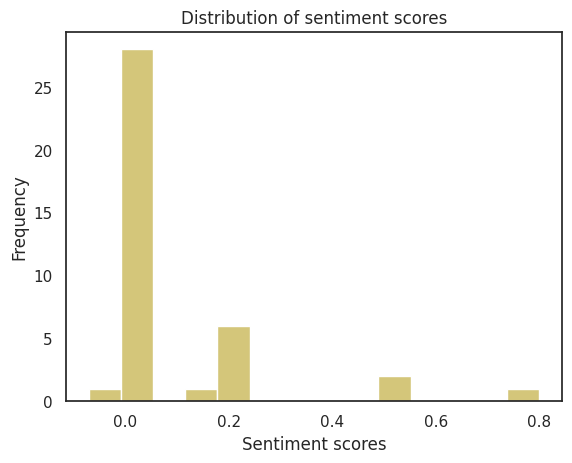

In [21]:
df['Feedback'] = df['Feedback'].fillna('')
df['Sentiment_Scores'] = df['Feedback'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

print(df['Sentiment_Scores'].describe())

sns.histplot(df['Sentiment_Scores'])
plt.title('Distribution of sentiment scores')
plt.ylabel('Frequency')
plt.xlabel('Sentiment scores')
plt.show()

In [22]:
df.sample(2)

,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Feedback,overall rating,Date,Time,Hour,Language,Word_Count,Sentiment_Scores
30,GOPESH DEY,22,Mangaldai college,Male,Course,Neutral,Low Facilities,Neutral,Fair,System,3,2025-11-12,17:07:56,17,Danish,1,0.0
38,DOLLA CHAKRABORTY,18,ARYA VIDYAPEETH COLLEGE AUTONOMOUS,Female,Support,Neutral,Understanding,Neutral,Excellent,,5,2025-11-13,00:16:12,0,NaN,0,0.0


In [23]:
def sentiment_analyzer(score):

    if score > 0.049889:
        return 'positive'

    elif score < 0.049889:
        return 'negative'

    else:
        return 'neutral'

df['Sentiments'] = df['Sentiment_Scores'].apply(sentiment_analyzer)
print(list(df['Sentiment_Scores']))

df['Sentiments'].value_counts()

[0.0, 0.0, 0.0, 0.55, 0.0, 0.2, 0.2, 0.0, 0.0, 0.2, 0.175, 0.2, 0.2, 0.0, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.07142857142857142, 0.20454545454545453, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.04999999999999996, 0.04999999999999996, 0.0, 0.0, 0.0]


,count
Sentiments,
negative,27
positive,12


In [24]:
from collections import Counter

# The keywords or phrases of interest
keywords = ['shit', 'difficult', 'terrible', 'okay', 'best', 'worst', 'good', 'try', 'bad']

# Concatenate all the preprocessed feedback into a single string
all_feedback = ' '.join(df['Feedback'])

# Tokenize the text into individual words
tokens = all_feedback.split()

# Count the frequency of each keyword in the feedback
keyword_frequency = Counter(tokens)

# Print the frequency of each keyword
for keyword in keywords:
    print(f"Frequency of '{keyword}': {keyword_frequency[keyword]}")

Frequency of 'shit': 0
Frequency of 'difficult': 0
Frequency of 'terrible': 0
Frequency of 'okay': 0
Frequency of 'best': 0
Frequency of 'worst': 0
Frequency of 'good': 0
Frequency of 'try': 0
Frequency of 'bad': 0


In [25]:
df


,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Feedback,overall rating,Date,Time,Hour,Language,Word_Count,Sentiment_Scores,Sentiments
0,Dipika Sarkar,18,Royal Global University,Female,Course,Neutral,Understanding,Less Motivated,Fair,not any,3,2025-11-10,23:51:24,23,Tagalog (Filipino),2,0.000000,negative
1,Nirok Asher G Momin,22,The Assam Royal Global University,Female,Resources,Neutral,Time Management,Neutral,Fair,not any,3,2025-11-11,00:12:27,0,Tagalog (Filipino),2,0.000000,negative
2,Dhanjita Boro,18,Pandit Deendayal Upadhyaya Adarsha mahavidyalaya,Female,Course,Neutral,Limited Resources,Neutral,Fair,I dunno,3,2025-11-11,21:41:41,21,Italian,2,0.000000,negative
3,Suzina parbin,22,The Assam Royal Global University,Female,Course,Satisfied,Time Management,Neutral,Good,Faculty should be more resourceful,4,2025-11-11,21:42:01,21,English,5,0.550000,positive
4,Afrida Begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,not any,5,2025-11-11,21:47:25,21,Tagalog (Filipino),2,0.000000,negative
5,Rishika singha,15,The Assam Royal Global University,Female,Course,Neutral,Limited Resources,Neutral,Fair,BA Geography related book should be available ...,3,2025-11-11,21:47:53,21,English,9,0.200000,positive
6,Afrida begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:50:16,21,English,25,0.200000,positive
7,Crosby Sangma,18,"St Edmunds College, Shillong",Prefer not to say,Course,Satisfied,Time Management,Neutral,Excellent,Practically Teaching,4,2025-11-11,21:50:39,21,English,2,0.000000,negative
8,Chebanora M Momin,18,The Assam Royal Global University,Female,Resources,Satisfied,Time Management,Neutral,Fair,practically Teaching,5,2025-11-11,21:50:52,21,English,2,0.000000,negative
9,Afrida begum,18,Rahman Institute of nursing and paramadical sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:51:32,21,English,25,0.200000,positive


In [26]:
vectorizer = CountVectorizer(max_features=1000, lowercase=True, stop_words='english', ngram_range=(1, 2))

dtm = vectorizer.fit_transform(df['Feedback'])
num_topics = 10
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(dtm)

feature_names = vectorizer.get_feature_names_out()
top_words = 10
for topic_idx, topic in enumerate(lda.components_):
    print(f"Topic {topic_idx}:")
    print(" ".join([feature_names[i] for i in topic.argsort()[:-top_words - 1:-1]]))
    print()

Topic 0:
teaching focus teaching different teaching real real focus teaching life challenges real life life different

Topic 1:
just needed thestream great thestream personalities education needed just great personalities great personalities just flow

Topic 2:
raising single hand single betterment point hand hand betterment point raising point betterment dunno

Topic 3:
updating updating curricula support support students structure clinical structure technology improving technology students quality structure

Topic 4:
practically practically teaching teaching improvement dunno painting school school painting focus sports

Topic 5:
related library book related book ba geography geography related book available available available library

Topic 6:
expenses fees fees expenses dunno improvement school painting painting school focus day

Topic 7:
resourceful faculty faculty resourceful dunno improvement school painting school painting focus day

Topic 8:
dunno improvement school painting 

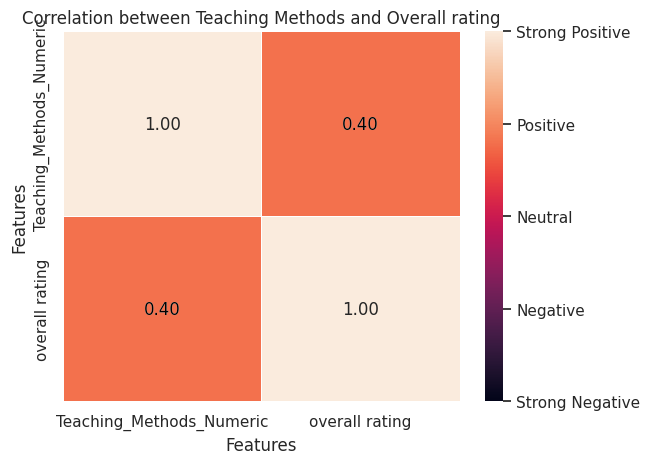

In [27]:
teaching_methods_mapping = {
    'Very Dissatisfied': 0,
    'Dissatisfied': 1,
    'Neutral': 2,
    'Satisfied': 3,
    'Very Satisfied': 4
}

df['Teaching_Methods_Numeric'] = df['How do you feel about the teaching methods used in your classes?'].map(teaching_methods_mapping)

correlation_matrix = df[['Teaching_Methods_Numeric', 'overall rating']].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation between Teaching Methods and Overall rating')

for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        if i != j:
            text = '{:.2f}'.format(correlation_matrix.iloc[i, j])
            plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black')

colorbar = plt.gca().collections[0].colorbar
colorbar.set_ticks([-1, -0.5, 0, 0.5, 1])
colorbar.set_ticklabels(['Strong Negative', 'Negative', 'Neutral', 'Positive', 'Strong Positive'])

plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [28]:
def standardize_school_name(name):
    if isinstance(name, str):
        name = name.lower().strip()
        if 'royal global university' in name or 'rgu guwahati' in name:
            return 'Royal Global University'
        elif 'rahman institute of nursing' in name or 'rahman institute of nursing and paramedical science' in name or 'rahman institute of nursing and paramedical sciences' in name:
            return 'Rahman Institute of Nursing and Paramedical Science'
        elif 'pandit deendayal upadhyaya adarsha mahavidyalaya' in name or 'pduam' in name or 'PDUAM, DALGAON' in name:
            return 'Pandit Deendayal Upadhyaya Adarsha Mahavidyalaya'
        elif 'kjb senior secondary school' in name:
            return 'KJB Senior Secondary School'
        elif 'assam down town university' in name or 'assam downtown university' in name or 'adtu' in name:
            return 'Assam Down Town University'
        elif 'arya vidyapeeth college' in name:
            return 'Arya Vidyapeeth College (Autonomous)'
        elif 'mangaldai college' in name:
            return 'Mangaldai College'
        elif 'ulubari h.s. school' in name:
            return 'Ulubari H.S. School'
        elif 'srimanta sankerdev adarsha sishu l.p school' in name:
            return 'Srimanta Sankerdev Adarsha Sishu L.P. School'
        elif 'north eastern hill university shillong' in name:
            return 'North Eastern Hill University Shillong'
        elif 'dispur law college' in name:
            return 'Dispur Law College'
        elif 'rg baruah college' in name:
            return 'RG Baruah College'
        elif 'shri ramdeoboba college of engineering and management' in name:
            return 'Shri Ramdeoboba College of Engineering and Management'
        elif name == 'college': # Handle generic 'College' entry if it's meant to be grouped or corrected
            return 'Unknown College'
        return name.title() # Capitalize first letter of each word if no specific mapping found
    return name

df['School/College Name'] = df['School/College Name'].apply(standardize_school_name)

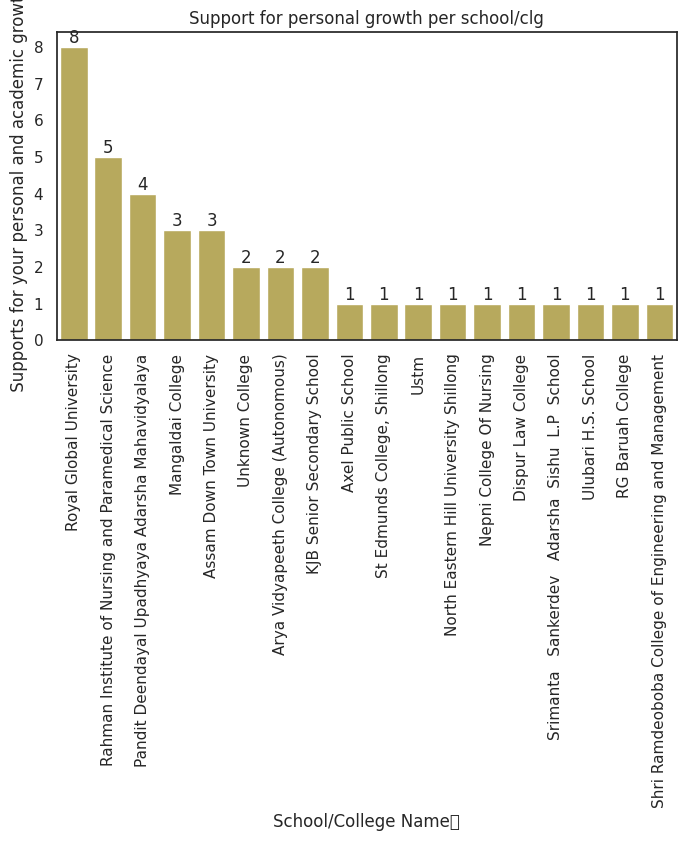

In [29]:
plt.figure(figsize=(8, 4))
order = df['School/College Name'].value_counts().index
ax = sns.countplot(data=df, x='School/College Name', order=order)
plt.xlabel('School/College Name	')
plt.ylabel(' Supports for your personal and academic growth?')
plt.title('Support for personal growth per school/clg')
plt.xticks(rotation=90)
ax.bar_label(ax.containers[0], fmt='%.0f', label_type='edge')
plt.show()

In [30]:
unique_schools_cleaned = df['School/College Name'].unique()
print("Participating Schools/Colleges (Cleaned):")
for school in unique_schools_cleaned:
    print(school)

num_participating_institutions_cleaned = df['School/College Name'].nunique()
print(f"\nNumber of participating schools/colleges (Cleaned): {num_participating_institutions_cleaned}")

Participating Schools/Colleges (Cleaned):
Royal Global University
Pandit Deendayal Upadhyaya Adarsha Mahavidyalaya
Rahman Institute of Nursing and Paramedical Science
St Edmunds College, Shillong
Axel Public School
Mangaldai College
Nepni College Of Nursing
Unknown College
North Eastern Hill University Shillong
Ustm
Assam Down Town University
Dispur Law College
Arya Vidyapeeth College (Autonomous)
Srimanta   Sankerdev   Adarsha  Sishu  L.P  School
Ulubari H.S. School
KJB Senior Secondary School
RG Baruah College
Shri Ramdeoboba College of Engineering and Management

Number of participating schools/colleges (Cleaned): 18


In [31]:
df

,Your Name,Age Group,School/College Name,Gender,What do you like most about your education experience ?,How do you feel about the teaching methods used in your classes?,What are the biggest challenges you face in your studies?,How motivated do you feel to participate in class activities?,How do you feel the school supports for your personal and academic growth?,Feedback,overall rating,Date,Time,Hour,Language,Word_Count,Sentiment_Scores,Sentiments,Teaching_Methods_Numeric
0,Dipika Sarkar,18,Royal Global University,Female,Course,Neutral,Understanding,Less Motivated,Fair,not any,3,2025-11-10,23:51:24,23,Tagalog (Filipino),2,0.000000,negative,2
1,Nirok Asher G Momin,22,Royal Global University,Female,Resources,Neutral,Time Management,Neutral,Fair,not any,3,2025-11-11,00:12:27,0,Tagalog (Filipino),2,0.000000,negative,2
2,Dhanjita Boro,18,Pandit Deendayal Upadhyaya Adarsha Mahavidyalaya,Female,Course,Neutral,Limited Resources,Neutral,Fair,I dunno,3,2025-11-11,21:41:41,21,Italian,2,0.000000,negative,2
3,Suzina parbin,22,Royal Global University,Female,Course,Satisfied,Time Management,Neutral,Good,Faculty should be more resourceful,4,2025-11-11,21:42:01,21,English,5,0.550000,positive,3
4,Afrida Begum,18,Rahman Institute of Nursing and Paramedical Sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,not any,5,2025-11-11,21:47:25,21,Tagalog (Filipino),2,0.000000,negative,4
5,Rishika singha,15,Royal Global University,Female,Course,Neutral,Limited Resources,Neutral,Fair,BA Geography related book should be available ...,3,2025-11-11,21:47:53,21,English,9,0.200000,positive,2
6,Afrida begum,18,Rahman Institute of Nursing and Paramedical Sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:50:16,21,English,25,0.200000,positive,4
7,Crosby Sangma,18,"St Edmunds College, Shillong",Prefer not to say,Course,Satisfied,Time Management,Neutral,Excellent,Practically Teaching,4,2025-11-11,21:50:39,21,English,2,0.000000,negative,3
8,Chebanora M Momin,18,Royal Global University,Female,Resources,Satisfied,Time Management,Neutral,Fair,practically Teaching,5,2025-11-11,21:50:52,21,English,2,0.000000,negative,3
9,Afrida begum,18,Rahman Institute of Nursing and Paramedical Sc...,Female,Course,Very Satisfied,Understanding,Very Motivated,Excellent,updating curricula to reflect modern healthcar...,5,2025-11-11,21:51:32,21,English,25,0.200000,positive,4


<Figure size 1200x700 with 0 Axes>

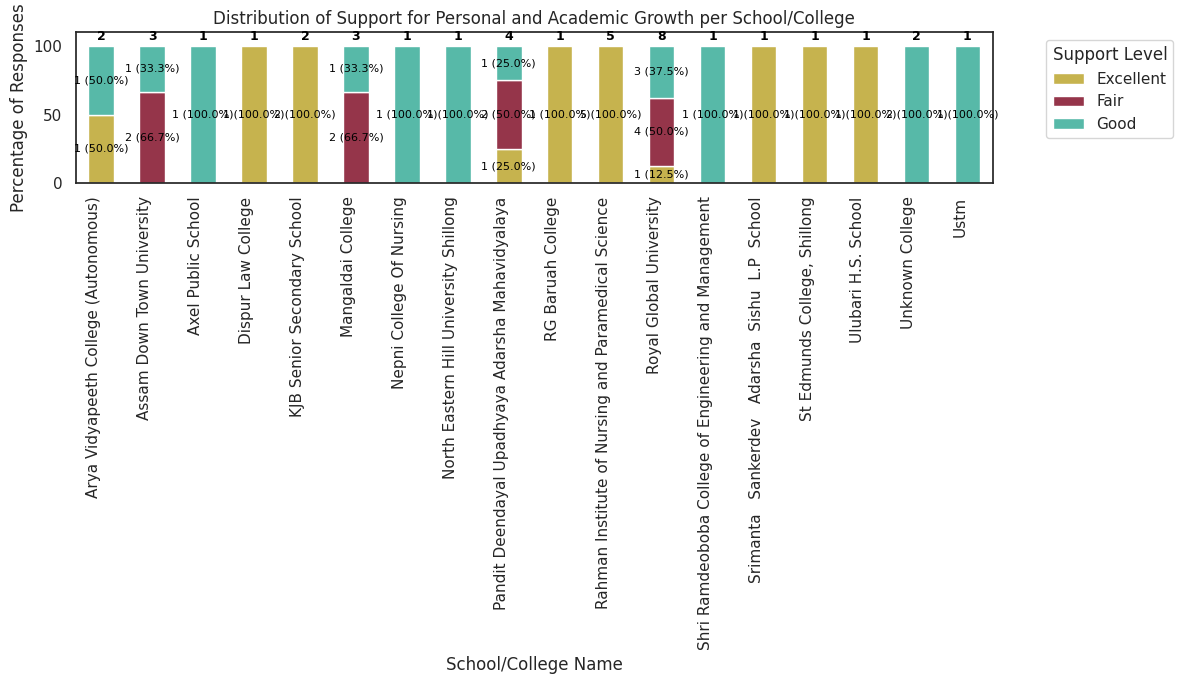

In [32]:
plt.figure(figsize=(12, 7)) # Adjusting figure size for vertical display
sns.set_palette(my_palette)

school_support_counts = df.groupby(['School/College Name', 'How do you feel the school supports for your personal and academic growth?']).size().unstack(fill_value=0)
school_support_percentage = school_support_counts.apply(lambda x: x / x.sum() * 100, axis=1)

ax = school_support_percentage.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Distribution of Support for Personal and Academic Growth per School/College')
plt.xlabel('School/College Name')
plt.ylabel('Percentage of Responses')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Support Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add labels for each segment (raw count and percentage)
for i, container in enumerate(ax.containers):
    current_support_level = school_support_percentage.columns[i]
    labels = []
    for bar_idx, bar in enumerate(container):
        if bar.get_height() > 0:
            percentage = bar.get_height()
            school_name = school_support_percentage.index[bar_idx]
            raw_count = school_support_counts.loc[school_name, current_support_level]
            labels.append(f'{raw_count} ({percentage:.1f}%)')
        else:
            labels.append('')
    ax.bar_label(container, labels=labels, label_type='center', color='black', fontsize=8)

# Add total frequency at the top of each stacked bar
total_school_counts = school_support_counts.sum(axis=1)
for i, total_count in enumerate(total_school_counts):
    ax.text(i, 100 + 2, f'{total_count}', ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')

plt.ylim(0, 110) # Adjust y-axis limit to make space for total labels
plt.tight_layout()
plt.show()

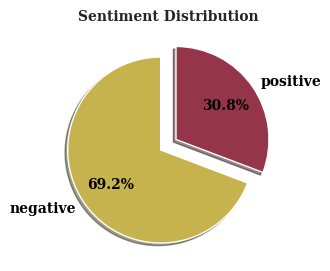

In [33]:
label_data = df['Gender'].value_counts()
explode = (0.1, 0.1, 0.1)
label_data = df['Sentiments'].value_counts()
explode = (0.1, 0.1)
plt.figure(figsize=(3, 4))
patches, texts, pcts = plt.pie(label_data,labels = label_data.index,pctdistance = 0.65,shadow = True,startangle = 90,explode = explode,
                               autopct = '%1.1f%%',textprops={ 'fontsize': 10,'color': 'black','weight': 'bold','family': 'serif' })
plt.setp(pcts, color='Black')
hfont = {'fontname':'serif', 'weight': 'bold'}
plt.title('Sentiment Distribution', size=10, **hfont)
fig = plt.gcf()

plt.show()

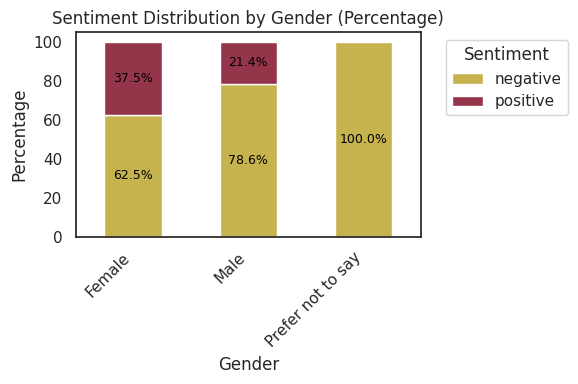

In [34]:
sentiment_gender_counts = df.groupby(['Gender', 'Sentiments']).size().unstack(fill_value=0)
sentiment_gender_percentage = sentiment_gender_counts.apply(lambda x: x / x.sum() * 100, axis=1)

ax = sentiment_gender_percentage.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Sentiment Distribution by Gender (Percentage)')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    labels = [f'{w.get_height():.1f}%' if w.get_height() > 0 else '' for w in container]
    ax.bar_label(container, labels=labels, label_type='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()                        # Stacked bar chart is used

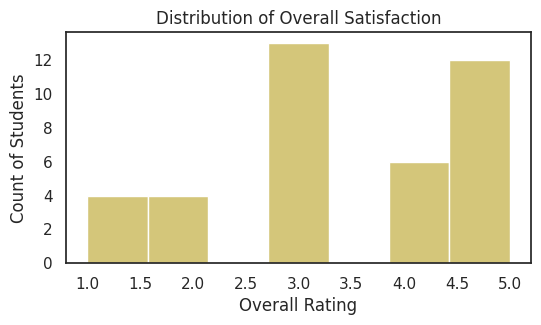

In [35]:
plt.figure(figsize=(6, 3))
sns.histplot(data=df, x='overall rating')
plt.xlabel('Overall Rating')
plt.ylabel('Count of Students')
plt.title('Distribution of Overall Satisfaction')
plt.show()

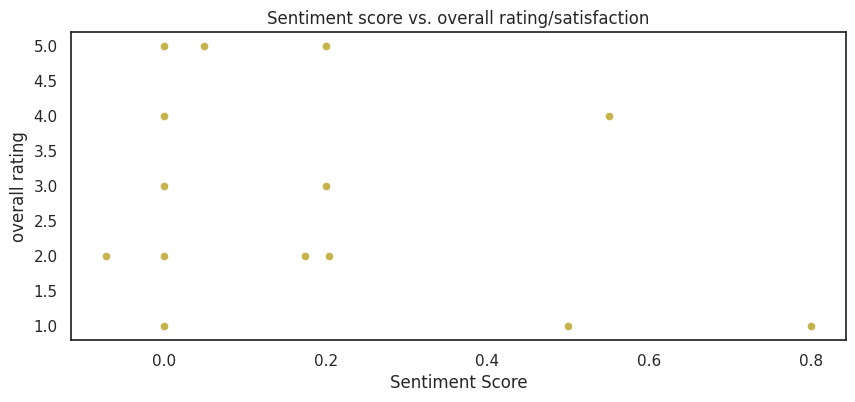

In [36]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x='Sentiment_Scores', y='overall rating', data=df)
plt.xlabel('Sentiment Score')
plt.ylabel('overall rating')
plt.title('Sentiment score vs. overall rating/satisfaction')
plt.show()

In [37]:
X = df['Feedback']
y = df['Sentiments']

print(len(X), ',', len(y))

39 , 39


In [38]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Encoded Target Labels:')
print(y_encoded, '\n')

# get mapping for each label
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label Mappings:')
print(le_name_mapping)

Encoded Target Labels:
[0 0 0 1 0 1 1 0 0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0
 0 0] 

Label Mappings:
{'negative': np.int64(0), 'positive': np.int64(1)}


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(31,) (31,)
(8,) (8,)


In [40]:
# Using random train and test subsets

# Preprocessor
preprocessor = Pipeline([
    ('bow', CountVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer()),
])

model = xgb.XGBClassifier(
    eta=0.01,
    max_depth=7,
    n_estimators=100,
    objective='binary:logistic',
    eval_metric='logloss',
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model),
])

# Fit the pipeline to the train data
pipeline.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = pipeline.predict(X_test)

# Calculate the accuracy score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

# Calculate the recall score
recall_xgb = recall_score(y_test, y_pred_xgb)

# Calculate the precision score
precision_xgb = precision_score(y_test, y_pred_xgb)

# Calculate the f1-score
f1_xgb = f1_score(y_test, y_pred_xgb)

# Print the results
print('Accuracy score: {:.3f} %'.format(accuracy_xgb * 100))
print('Recall score: {:.3f}'.format(recall_xgb))
print('Precision score: {:.3f}'.format(precision_xgb))
print('F1-score: {:.3f}'.format(f1_xgb))

Accuracy score: 75.000 %
Recall score: 0.000
Precision score: 0.000
F1-score: 0.000


In [41]:
# using cross validation techniques

preprocessor = Pipeline([
    ('bow', CountVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer()),
])

model_cv = xgb.XGBClassifier(
    eta=0.01,
    max_depth=10,
    n_estimators=100,
    objective='binary:logistic',
    eval_metric='logloss',
)


pipeline_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_cv),
])

kf = KFold(n_splits=10, shuffle=True, random_state=0)
cv_scores = cross_val_score(pipeline_cv, X, y_encoded, cv=kf)
mean_cv_score = cv_scores.mean()
print('Cross-validation accuracy score: {:.3f} %'.format(mean_cv_score*100))

Cross-validation accuracy score: 69.167 %


The following code block is for training an XGBoost model using random train and test subsets and evaluating its performance. It can be found in cell `y6YvwtrpQAlR`.

In [42]:
# Using random train and test subsets

preprocessor = Pipeline([
    ('bow', CountVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer()),
])

### Preprocessor Pipeline

This section defines a `Pipeline` named `preprocessor` to transform the text data before it's fed into the machine learning model. A pipeline is a sequence of data transformers and estimators.

*   `preprocessor = Pipeline([ ... ])`: Initializes a scikit-learn `Pipeline` object.
*   `('bow', CountVectorizer(stop_words='english', ngram_range=(1, 2)))`: The first step in the pipeline is a `CountVectorizer`. It converts a collection of text documents to a matrix of token counts.
    *   `stop_words='english'`: Removes common English stop words (like 'the', 'a', 'is') which usually don't carry much sentiment.
    *   `ngram_range=(1, 2)`: Extracts unigrams (single words) and bigrams (two-word phrases) from the text. This helps capture more context than just single words.
*   `('tfidf', TfidfTransformer())`: The second step is a `TfidfTransformer`. After counting words, TF-IDF (Term Frequency-Inverse Document Frequency) transforms these counts into normalized TF-IDF representations. This weights words based on how frequently they appear in a document relative to their frequency across all documents, giving more importance to rare but significant words.

In [43]:
model = xgb.XGBClassifier(
    eta=0.01,
    max_depth=7,
    n_estimators=100,
    objective='binary:logistic',
    eval_metric='logloss',
)

### XGBoost Classifier Initialization

This code initializes the XGBoost classifier model with specific hyperparameters.

*   `model = xgb.XGBClassifier(...)`: Creates an instance of the `XGBClassifier`.
*   `eta=0.01`: This is the learning rate, also known as `learning_rate`. It shrinks the step size to prevent overfitting. A smaller value makes the boosting process more conservative.
*   `max_depth=7`: The maximum depth of a tree. Increasing this value makes the model more complex and prone to overfitting. `7` is a common choice.
*   `n_estimators=100`: The number of boosting rounds or the number of trees to build. More estimators can lead to better performance but also increase computation time and potential for overfitting.
*   `objective='binary:logistic'`: Specifies the learning task and the corresponding learning objective. `'binary:logistic'` means it's a binary classification problem (predicting one of two classes, 'negative' or 'positive'), and it will output logistic probabilities (values between 0 and 1).
*   `eval_metric='logloss'`: The evaluation metric used for validation data. `logloss` (logarithmic loss) is commonly used for binary classification, measuring the performance of a classification model where the prediction is a probability value between 0 and 1.

In [44]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model),
])

### Full Pipeline Construction

This combines the preprocessor and the XGBoost model into a single, comprehensive pipeline.

*   `pipeline = Pipeline([ ... ])`: Defines the final pipeline.
*   `('preprocessor', preprocessor)`: The first step is the `preprocessor` pipeline defined earlier, which handles text vectorization and TF-IDF transformation.
*   `('model', model)`: The second step is the `model` (XGBoost classifier) itself. When `pipeline.fit()` is called, the data will first pass through the `preprocessor`'s `fit_transform()` method, and then the transformed data will be used to `fit()` the `model`.

In [45]:
# Fitting the pipeline to the train data
pipeline.fit(X_train, y_train)

# Making the predictions on the test data
y_pred_xgb = pipeline.predict(X_test)

### Training and Prediction

*   `pipeline.fit(X_train, y_train)`: This command trains the entire pipeline using the training data (`X_train` for features, `y_train` for labels). The preprocessor first transforms `X_train`, and then the XGBoost model learns from the transformed features and `y_train`.
*   `y_pred_xgb = pipeline.predict(X_test)`: After training, this line uses the trained pipeline to make predictions on the unseen test data (`X_test`). The `X_test` data goes through the same preprocessing steps (transformation only, not fitting) and then the trained XGBoost model outputs sentiment predictions (`0` or `1`) for each feedback entry in `X_test`.

In [46]:
# Calculate the accuracy score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

# Calculate the recall score
recall_xgb = recall_score(y_test, y_pred_xgb)

# Calculate the precision score
precision_xgb = precision_score(y_test, y_pred_xgb)

# Calculate the f1-score
f1_xgb = f1_score(y_test, y_pred_xgb)

# Print the results
print('Accuracy score: {:.3f} %'.format(accuracy_xgb * 100))
print('Recall score: {:.3f}'.format(recall_xgb))
print('Precision score: {:.3f}'.format(precision_xgb))
print('F1-score: {:.3f}'.format(f1_xgb))

Accuracy score: 75.000 %
Recall score: 0.000
Precision score: 0.000
F1-score: 0.000


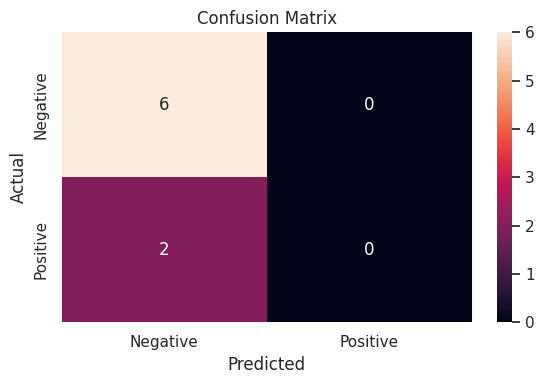

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative',  'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [48]:
# Preprocessor
preprocessor = Pipeline([
    ('bow', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
])

svm_model = SVC()

pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', svm_model),
])

pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)

# Calculating the accuracy score
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Calculating the recall score
recall_svm = recall_score(y_test, y_pred_svm)

# Calculating the precision score
precision_svm = precision_score(y_test, y_pred_svm)

# Calculating the f1-score
f1_svm = f1_score(y_test, y_pred_svm)

# Print the results
print('Accuracy score: {:.3f} %'.format(accuracy_svm * 100))
print('Recall score: {:.3f}'.format(recall_svm))
print('Precision score: {:.3f}'.format(precision_svm))
print('F1-score: {:.3f}'.format(f1_svm))

Accuracy score: 100.000 %
Recall score: 1.000
Precision score: 1.000
F1-score: 1.000


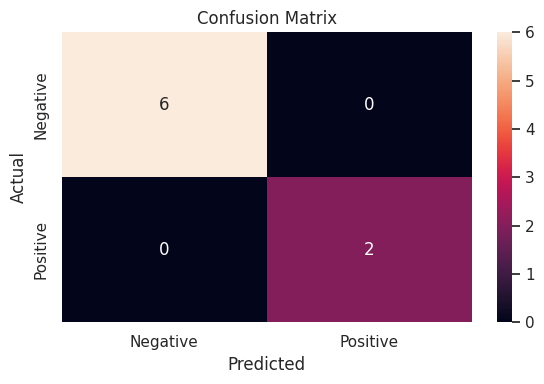

In [49]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative',  'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [50]:
from sklearn.naive_bayes import MultinomialNB

preprocessor = Pipeline([
    ('bow', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
])

naive_bayes = MultinomialNB()

pipeline_nb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', naive_bayes),
])

pipeline_nb.fit(X_train, y_train)
y_pred_nb = pipeline_nb.predict(X_test)

# Calculating the accuracy score
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# Calculating the recall score
recall_nb = recall_score(y_test, y_pred_nb)

# Calculating the precision score
precision_nb = precision_score(y_test, y_pred_nb)

# Calculating the f1-score
f1_nb = f1_score(y_test, y_pred_nb)

print('Accuracy score: {:.3f} %'.format(accuracy_nb * 100))
print('Recall score: {:.3f}'.format(recall_nb))
print('Precision score: {:.3f}'.format(precision_nb))
print('F1-score: {:.3f}'.format(f1_nb))

Accuracy score: 75.000 %
Recall score: 0.000
Precision score: 0.000
F1-score: 0.000


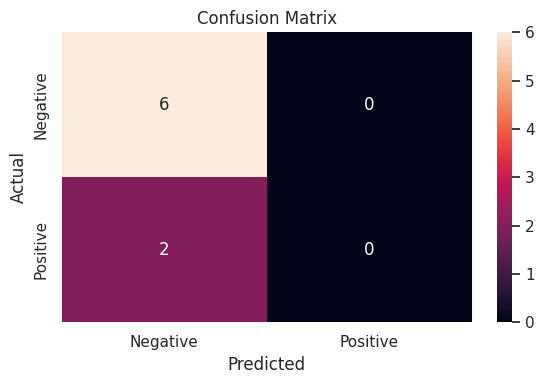

In [51]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative',  'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

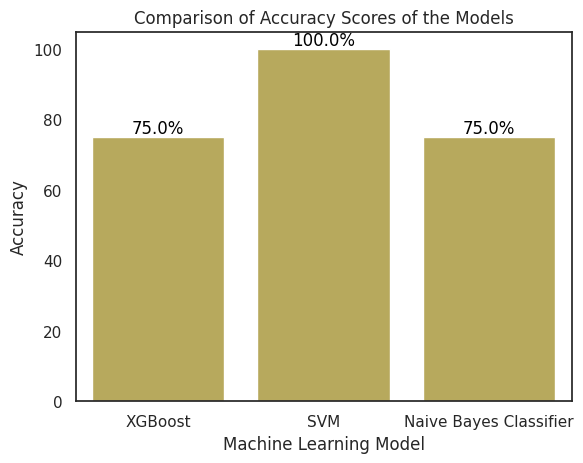

In [52]:
color = sns.color_palette()[0]
models = ['XGBoost', 'SVM', 'Naive Bayes Classifier']
accuracies = [accuracy_xgb*100, accuracy_svm*100, accuracy_nb*100]

ax = sns.barplot(x=models,
            y=accuracies,
            color=color)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', color='black')

plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracy Scores of the Models')

plt.show()

In [53]:
print('Accuracy score for XGBoost: {:.3f} %'.format(accuracy_xgb * 100))
print('Accuracy score for SVM: {:.3f} %'.format(accuracy_svm * 100))
print('Accuracy score for Naive Bayes Classifier: {:.3f} %'.format(accuracy_nb * 100))

Accuracy score for XGBoost: 75.000 %
Accuracy score for SVM: 100.000 %
Accuracy score for Naive Bayes Classifier: 75.000 %


In [54]:
new_feedback = "We are disapoint with the Facility provided in the classroom. "

# model Predicting the sentiment of the new feedback data
predicted_sentiment_encoded = pipeline_svm.predict([new_feedback])


predicted_sentiment_label = le.inverse_transform(predicted_sentiment_encoded)

print(f"New Feedback: '{new_feedback}'")
print(f"Predicted Sentiment: {predicted_sentiment_label[0]}")

New Feedback: 'We are disapoint with the Facility provided in the classroom. '
Predicted Sentiment: negative


PICKLING IS DONE

In [55]:
import pickle

In [56]:

with open('xgboost_model.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

print("XGBoost model pipeline saved to 'xgboost_model.pkl'")

XGBoost model pipeline saved to 'xgboost_model.pkl'


In [57]:

with open('svm_model.pkl', 'wb') as file:
    pickle.dump(pipeline_svm, file)

print("SVM model pipeline saved to 'svm_model.pkl'")

SVM model pipeline saved to 'svm_model.pkl'


In [58]:

with open('naive_bayes_model.pkl', 'wb') as file:
    pickle.dump(pipeline_nb, file)

print("Naive Bayes model pipeline saved to 'naive_bayes_model.pkl'")

Naive Bayes model pipeline saved to 'naive_bayes_model.pkl'


In [59]:
import pickle

#LOADING PICKLE MODEL
with open('xgboost_model.pkl', 'rb') as file:
    loaded_pipeline_xgb = pickle.load(file)
print("XGBoost model pipeline loaded successfully.")


with open('svm_model.pkl', 'rb') as file:
    loaded_pipeline_svm = pickle.load(file)
print("SVM model pipeline loaded successfully.")


with open('naive_bayes_model.pkl', 'rb') as file:
    loaded_pipeline_nb = pickle.load(file)
print("Naive Bayes model pipeline loaded successfully.\n")

# Testing Prediction with Loaded pickle
new_feedback_test = "The service was absolutely terrible and I am very unhappy. But my friend was satisfied with it."
predicted_sentiment_loaded = loaded_pipeline_svm.predict([new_feedback_test])
predicted_sentiment_label_loaded = le.inverse_transform(predicted_sentiment_loaded)

print(f"New Feedback for test: '{new_feedback_test}'")
print(f"Predicted Sentiment (from loaded SVM model): {predicted_sentiment_label_loaded[0]}")

XGBoost model pipeline loaded successfully.
SVM model pipeline loaded successfully.
Naive Bayes model pipeline loaded successfully.

New Feedback for test: 'The service was absolutely terrible and I am very unhappy. But my friend was satisfied with it.'
Predicted Sentiment (from loaded SVM model): negative


In [60]:
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(new_feedback_test)
print(f"Original feedback: '{new_feedback_test}'")
print(f"Tokenized sentences: {sentences}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original feedback: 'The service was absolutely terrible and I am very unhappy. But my friend was satisfied with it.'
Tokenized sentences: ['The service was absolutely terrible and I am very unhappy.', 'But my friend was satisfied with it.']


In [61]:
for sentence in sentences:
    predicted_sentiment_encoded = loaded_pipeline_svm.predict([sentence])
    predicted_sentiment_label = le.inverse_transform(predicted_sentiment_encoded)
    print(f"Sentence: '{sentence}' -> Predicted Sentiment: {predicted_sentiment_label[0]}")

Sentence: 'The service was absolutely terrible and I am very unhappy.' -> Predicted Sentiment: negative
Sentence: 'But my friend was satisfied with it.' -> Predicted Sentiment: negative


In [62]:
new_feedb_test2= "Professor did a small mistake today. Overall it was a interesting session today."
predicted_sentiment_loaded = loaded_pipeline_svm.predict([new_feedb_test2])
predicted_sentiment_label_loaded = le.inverse_transform(predicted_sentiment_loaded)
print(f"New Feedback for test: '{new_feedb_test2}'")
print(f"Predicted Sentiment: {predicted_sentiment_label_loaded[0]}")

New Feedback for test: 'Professor did a small mistake today. Overall it was a interesting session today.'
Predicted Sentiment: negative


In [63]:
from textblob import TextBlob

#  Defining the specific sentence
new_feedb_test2 = "Professor did a small mistake today. Overall it was a interesting session today."

#  Use TextBlob to analyze the sentence
sentiment_blob = TextBlob(new_feedb_test2)

# Print the polarity score
polarity_score = sentiment_blob.sentiment.polarity
print(f"TextBlob Polarity Score: {polarity_score}")

# Printing the subjectivity score
subjectivity_score = sentiment_blob.sentiment.subjectivity
print(f"TextBlob Subjectivity Score: {subjectivity_score}")

#  Manually applying the logic of the sentiment_analyzer function
def custom_sentiment_analyzer(score):
    threshold = 0.049889
    if score > threshold:
        return 'positive'
    elif score < threshold:
        return 'negative'
    else:
        return 'neutral'

classified_sentiment = custom_sentiment_analyzer(polarity_score)
print(f"Classified Sentiment using custom_sentiment_analyzer (threshold={0.049889}): {classified_sentiment}")

TextBlob Polarity Score: 0.08333333333333333
TextBlob Subjectivity Score: 0.3
Classified Sentiment using custom_sentiment_analyzer (threshold=0.049889): positive


In [64]:
new_feedback_example = 'The facilities provided are excellent, but the teaching staff needs improvement.'
print(f"New feedback example created: {new_feedback_example}")

New feedback example created: The facilities provided are excellent, but the teaching staff needs improvement.


In [65]:
predicted_sentiment_encoded = loaded_pipeline_svm.predict([new_feedback_example])
predicted_sentiment_label = le.inverse_transform(predicted_sentiment_encoded)

print(f"New Feedback: '{new_feedback_example}'")
print(f"Predicted Sentiment: {predicted_sentiment_label[0]}")

New Feedback: 'The facilities provided are excellent, but the teaching staff needs improvement.'
Predicted Sentiment: negative


In [66]:
pickle.dump(loaded_pipeline_svm, open('sentiment_model.pkl', 'wb'))
print("Sentiment analysis model pipeline saved to 'sentiment_model.pkl'")

Sentiment analysis model pipeline saved to 'sentiment_model.pkl'
